# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**: Jerry Lu

**ID**: jl3498

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\shini\hw2-jerry`


In [2]:
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

Atmospheric CO2--(+)-->Global Mean Temperature

        ↑
        |                       |
        
        |                       |
       (-)                     (-)
        |                       |

        |                       |
                                ↓

        Ocean CO2 Concentrations

This suggests a positive feedback loop between temperature and ocean carbon cycle. Since atmospheric CO2 warms the planet, less ocean CO2 uptake and more CO2 stays in the atmosphere, meaning higher temperature.


> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.

### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 

<figure>
<img src="attachment:figures/river_diagram.png"
alt="Schematic of the river system in Problem 2" />
<figcaption aria-hidden="true">Schematic of the river system in Problem
2</figcaption>
</figure>

#### Problem 2.1

Draw a systems diagram with the relevant control volume(s) denoted and
any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?

Control Volume 1 
|River Inflow to Discharge 1|  
--------------------------
River Flow=(Q_1,C_1)  
River Inflow=(250,000 $\text m^{3}$/d)  
Inflow Concentration=(0.5 kg/1000 $\text m^{3}$)  
Decay rate: 0.36 $\text d^{-1}$  
Discharges of wastewater contaminated with CRUD 1=(40,000 $\text m^{3}$/d, 9kg/1000 $\text m^{3}$)   

Control Volume 2   
|Discharge 1 to Discharge 2|  
-------------------------- 
River Flow=(Q_2,C_2)  
L=15km  
Decay rate: 0.36 $\text d^{-1}$   
Discharges of wastewater contaminated with CRUD 2=(60,000 $\text m^{3}$/d, 7kg/1000 $\text m^{3}$)  

Control Volume 3  
|Discharge 2 to downstream|  
----------------------------
River Flow=(Q_3,C_3)  
Decay rate: 0.36 $\text d^{-1}$   

CRUD deposited by the atomsphere=(54 kg/km/d)  


Three boxes were used to determine the concentration of discharge from the river inflow to the 1st discharge, between discharges, and after the 2nd discharge. This allows you to understand the inflows and outflows for each part of the system.

#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.

> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

In [ ]:
#Given Parameters
river_flow=10 #km/d
river_inflow=250000 #m^3/d
conc_inflow=0.5/1000 #kg/m^3
decay=0.36 #d^-1
Atm=54 #kg/km/d
Q_1=40000 #m^3/d
C_1=9/1000 #kg/m^3
Q_2=60000 #m^3/d
C_2=7/1000 #kg/m^3
L=15 #km

# Initial cross-sectional area of the river
Area=river_inflow/(river_flow*1000) #m^2

# Control Volume 1
# dC/dx=-decay/river_flow*C+Atm/(Area*river_flow)
# Rearranging to standard form:dC/dx+(decay/river_flow)*C=Atm/(Area*river_flow)
# Analytical solution C(x)=(Atm/(Area*river_flow)/(decay/river_flow))+K*exp(-a*x)
C1_particular=((Atm/(Area*river_flow))/(decay/river_flow))

# Finding constant K using boundary condition at inflow
K1=conc_inflow-C1_particular
C1(x)=C1_particular+K1*exp(-(decay / river_flow)*x)

# Concentration at the end of CV1
C_at_1st_discharge=C1(0)

# Control Volume 2
# Mixed concentration after 1st discharge
Q_after_1st_discharge=river_inflow+Q_d1
C_after_1st_discharge=(conc_inflow*river_inflow+C_d1*Q_d1)/Q_after_1st_discharge
Area_after_1st_discharge=Q_after_1st_discharge/(river_flow*1000) #m^2

C2_particular=((Atm/(Area_after_1st_discharge*river_flow))/(decay/river_flow))
K2=C_after_1st_discharge-C2_particular
C2(x)=C2_particular+K2*exp(-a2*x)

# Concentration at the end of CV2
C_at_2nd_discharge=C2(L)

# Control Volume 3
# Mixed concentration after 2nd discharge
Q_after_2nd_discharge=Q_after_1st_discharge+Q_2
C_after_2nd_discharge=(C_at_2nd_discharge*Q_after_1st_discharge+C_2*Q_2)/Q_after_2nd_discharge
Area_after_2nd_discharge=Q_after_2nd_discharge/(river_flow * 1000) #m^2

C3_particular=((Atm/(Area_after_2nd_discharge*river_flow))/(decay/river_flow))
K3 = C_after_2nd_discharge - C3_particular
C3(x) = C3_particular + K3 * exp(-a3 * x_)


C3 (generic function with 1 method)

This uses the equation dC/dx=-decay/river_flow*C+Atm/(Area*river_flow) to find the concentration of KRUD downriver after each discharge. By deriving the analytical solution C(x)=(Atm/(Area*river_flow)/(decay/river_flow))+K*exp(-a*x), we can find the concentration after each control volume. 

#### Problem 2.3

Determine if the system in compliance with a regulatory limit of
$2.3\ \text{kg}/(1000 \text{m}^3)$. You can do this analytically or
computationally.

In [30]:
#Given Parameters
river_flow=10 #km/d
river_inflow=250000 #m^3/d
conc_inflow=0.5/1000 #kg/m^3
decay=0.36 #d^-1
Atm=54 #kg/km/d
Q_1=40000 #m^3/d
C_1=9/1000 #kg/m^3
Q_2=60000 #m^3/d
C_2=7/1000 #kg/m^3
L=15 #km

# Initial cross-sectional area of the river
Area=river_inflow/(river_flow*1000) #m^2

# Control Volume 1
# dC/dx=-decay/river_flow*C+Atm/(Area*river_flow)
# Rearranging to standard form:dC/dx+(decay/river_flow)*C=Atm/(Area*river_flow)
# Analytical solution C(x)=(Atm/(Area*river_flow)/(decay/river_flow))+K*exp(-a*x)
C1_particular=((Atm/(Area*river_flow))/(decay/river_flow))

# Finding constant K using boundary condition at inflow
K1=conc_inflow-C1_particular
C1(x)=C1_particular+K1*exp(-(decay / river_flow)*x)

# Concentration at the end of CV1
C_at_1st_discharge=C1(0)

# Control Volume 2

# Mixed concentration after 1st discharge
Q_after_1st_discharge=river_inflow+Q_d1
C_after_1st_discharge=(conc_inflow*river_inflow+C_d1*Q_d1)/Q_after_1st_discharge
Area_after_1st_discharge=Q_after_1st_discharge/(river_flow*1000) #m^2

C2_particular=((Atm/(Area_after_1st_discharge*river_flow))/(decay/river_flow))
K2=C_after_1st_discharge-C2_particular
C2(x)=C2_particular+K2*exp(-a2*x)

# Concentration at the end of CV2
C_at_2nd_discharge=C2(L)

# Control Volume 3
# Mixed concentration after 2nd discharge
Q_after_2nd_discharge=Q_after_1st_discharge+Q_2
C_after_2nd_discharge=(C_at_2nd_discharge*Q_after_1st_discharge+C_2*Q_2)/Q_after_2nd_discharge

# regulatory limit
regulatory_limit= 2.3/1000 #kg/m^3


println("Concentration after 1st discharge:", round(C_after_1st_discharge, digits=5), " kg/m^3")
println("Concentration before 2nd discharge:", round(C_at_2nd_discharge_pre_mix, digits=5), " kg/m^3")
println("Concentration after 2nd discharge:", round(C_after_2nd_discharge, digits=5), " kg/m^3")


Concentration after 1st discharge:0.00167 kg/m^3
Concentration before 2nd discharge:2.15917 kg/m^3
Concentration after 2nd discharge:1.79023 kg/m^3


Since the regulatory limit is 2.3kg/1000m^3 which is .0023kg/1000m^3. Only the concentration after the 1st discharge meets the limit. The concentration before and after the 2nd discharge exceed past the limit. An interesting conclusion is that the concentration increases then deacreases after the 2nd discharge.

### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

Forward Euler: $ \frac{dT}{dt} = \frac{\Delta T(t)}{\Delta t} = \frac{T(t+\Delta t)-T(t)} {\Delta t}$

Substituting into the eq.: $C \frac{T(t+\Delta t)-T(t)} {\Delta t} = \frac {(1-\alpha)S} {4}-(A-BT(t))$

Solve for $T(t+\Delta t)$:

$T(t+\Delta t)=T(t)+ \frac{\Delta t}{C} [\frac {(1-\alpha)S} {4}-(A-BT(t))]$

Solving for $\Delta t =1$:

$T(t+1)=T(t)+ \frac{1}{C} [\frac {(1-\alpha)S} {4}-(A-BT(t))]$

$T(t+1)=T(t)+ \frac{1}{51{\frac {\text j} {\text m^{2}\degree \text C}}} [\frac {(1-.3)1272 \frac {{\text W}} {\text m^{2}}} {4}-221.2 \frac {{\text W}} {\text m^{2}} -(-1.3 \frac {{\text W}} {\text m^{2}\degree \text C})T(t)]$

$T(t+1)=T(t)+ \frac{1}{51{\frac {\text j} {\text m^{2}\degree \text C}}}[1.4 \frac {{\text W}} {\text m^{2}} -1.3 \frac {{\text W}} {\text m^{2}\degree \text C}T(t)]$



#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

Equilibrium temperatures found: [-47.85]

Stability analysis:
Equilibrium at -47.85°C (a = 0.5): Stable


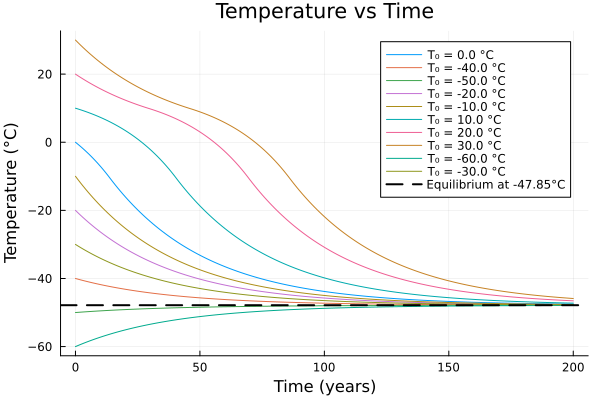

In [ ]:
#Given Parameters
C=51.0 #J/(m^2*°C))
S=1272.0 #W/m^2
A=221.2 #W/m^2
B=-1.3 #W/(m^2*°C)
a_i=.5 #if T<=-10°C)
a_0=.3 #if T>=10°C


function albedo(T)
    if T <= -10
        return a_i
    elseif T >= 10
        return a_0
    else
        return a_i + (a_0 - a_i) * ((T + 10) / 20)
    end
end

function climate_step(T_current)
    a= albedo(T_current)
    dT_dt=((1-a)*S/4 - A + B*T_current)/C
    return T_current + dT_dt
end

# Simulate over a range of initial temperatures
years= 200
T0_range=-60:10:30
trajectories=Dict{Float64, Vector{Float64}}()


# Run simulations for each initial temperature
for T_0 in T0_range
    T= Float64[T_0]
    for year in 1:years
        push!(T, climate_step(T[end]))
    end
    trajectories[T_0]=T
end

plt=plot(title="Temperature vs Time", xlabel="Time (years)", ylabel="Temperature (°C)")

for (T_0, T_traj) in trajectories
    plot!(0:years, T_traj, label="T₀ = $T_0 °C", linewidth=1)
end


function find_equilibrium(T_guess)
    T = T_guess
    for i in 1:1000
        a = albedo(T)
        dT_dt = ((1 - a) * S / 4 - A + B * T)/C
        T_new = T + dT_dt
        if abs(T_new - T) < 1e-6
            return T_new
        end
        T = T_new
    end
    return T
end


# Test multiple initial guesses to find distinct equilibria
test_points = [-50.0, -20.0, 0.0, 15.0, 25.0]
equilibria = Set{Float64}()

for point in test_points
    eq = find_equilibrium(point)
    if abs(((1 - albedo(eq)) * S / 4 - A + B * eq) / C) < 1e-4
        push!(equilibria, round(eq, digits=2))
    end
end


println("Equilibrium temperatures found: ", sort(collect(equilibria)))

# Analyze stability of each equilibrium
println("\nStability analysis:")
for eq in sort(collect(equilibria))
   
    T_above = eq + 0.1
    T_below = eq - 0.1
    
    dT_above = ((1 - albedo(T_above)) * S / 4 - A + B * T_above) / C
    dT_below = ((1 - albedo(T_below)) * S / 4 - A + B * T_below) / C
    
    if dT_above < 0 && dT_below > 0
        stability = "Stable"
    elseif dT_above > 0 && dT_below < 0
        stability = "Unstable"
    else
        stability = "Semi-stable"
    end
    
    a_eq = albedo(eq)
    println("Equilibrium at $(eq)°C (a = $(round(a_eq, digits=3))): $stability")
end

for eq in equilibria
    hline!([eq], linestyle=:dash, color=:black, linewidth=2, label="Equilibrium at $(eq)°C")
end

display(plt)


This code simulates the temperature using the albedo given over time through the discretized energy balance equation. 200 years of simulation was done from $-60 \degree C$ to $30 \degree C$. The equilibrium was found by iterating where dT/dt=0.

#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

SOLAR RADIATION EFFECT ON SNOWBALL EARTH
S (W/m²) | Final Temp (°C) | Status
---------|-----------------|--------
1200       | -54.8         | Snowball
1250       | -50.0         | Snowball
1300       | -45.2         | Snowball
1350       | -40.3         | Snowball
1400       | -35.5         | Snowball


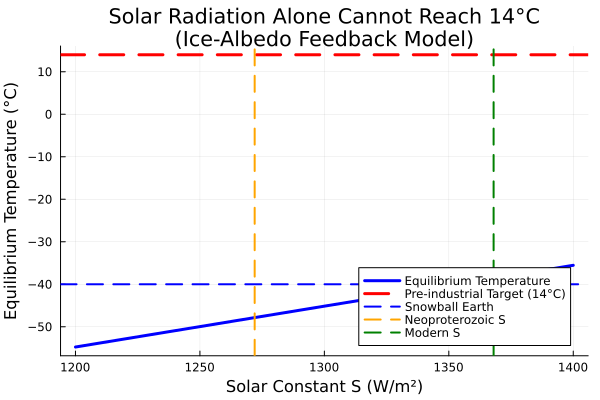

In [115]:
#Given Parameters
C=51.0 #J/(m^2*°C))
A=221.2 #W/m^2
B=-1.3 #W/(m^2*°C)
a_i=.5 #if T<=-10°C)
a_0=.3 #if T>=10°C

function albedo(T)
    if T <= -10
        return a_i
    elseif T >= 10
        return a_0
    else
        return a_i + (a_0 - a_i) * ((T + 10) / 20)
    end
end

function climate_step(T_current, S)
    a = albedo(T_current)
    dT_dt = ((1-a)*S/4 - A + B*T_current)/C
    return T_current + dT_dt
end

# Test multiple solar constants
S_range = 1200:10:1400
final_temperatures = Float64[]

println("SOLAR RADIATION EFFECT ON SNOWBALL EARTH")
println("="^50)
println("S (W/m²) | Final Temp (°C) | Status")
println("---------|-----------------|--------")

for S in S_range
    # Start from Snowball Earth conditions
    T = -40.0
    
    # Run simulation for 1000 years to reach equilibrium
    for year in 1:1000
        T = climate_step(T, S)
    end
    
    push!(final_temperatures, T)
    
    # Print key results
    if S % 25 == 0 || S == 1272 || S == 1368
        status = T < -20 ? "Snowball" : T >= 14 ? "Warm (14°C+)" : "Warm (<14°C)"
        println("$S       | $(round(T, digits=1))         | $status")
    end
end


plt = plot(S_range, final_temperatures, linewidth=3, 
           xlabel="Solar Constant S (W/m²)", 
           ylabel="Equilibrium Temperature (°C)",
           title="Solar Radiation Alone Cannot Reach 14°C\n(Ice-Albedo Feedback Model)",
           label="Equilibrium Temperature", 
           color=:blue, grid=true, legend=:bottomright)

# Add reference lines
hline!([14.0], linestyle=:dash, color=:red, linewidth=3, 
       label="Pre-industrial Target (14°C)")
hline!([-40.0], linestyle=:dash, color=:blue, linewidth=2, 
       label="Snowball Earth")
vline!([1272], linestyle=:dash, color=:orange, linewidth=2, 
       label="Neoproterozoic S")
vline!([1368], linestyle=:dash, color=:green, linewidth=2, 
       label="Modern S")

# Identify and mark bifurcation points
for i in 2:length(final_temperatures)
    if final_temperatures[i] - final_temperatures[i-1] > 5.0  # Sudden jump
        S_bifurcation = S_range[i]
        vline!([S_bifurcation], linestyle=:dash, color=:purple, linewidth=2, 
               label="Bifurcation Point")
        break
    end
end

display(plt)






No, solar increase alone is not able to warm the planet to $ 14\degree C$.

## References

List any external references consulted, including classmates.